# Reproducibility Notebook: Single-Pulse vs Explicit Echoed SQR

This notebook reproduces the echoed-extension deliverables for the study `multitone_sqr_arbitrary_fock_conditional_rotations`. The previous report tested only a single Gaussian multitone SQR pulse. The updated report and this notebook now load the explicit echoed comparison outputs based on the time-ordered pulse schedule `half SQR -> X_pi -> half SQR -> X_pi`.

Tensor-order convention used throughout: qubit `⊗` cavity, consistent with `cqed_sim`. The restricted logical basis is therefore ordered as `(|g,0>, |e,0>, |g,1>, |e,1>, ...)`.

Main goals:
- Confirm explicitly that the earlier study was single-pulse only.
- Inspect the saved comparison between `single_pulse`, `echoed_fixed_total`, and `echoed_fixed_active`.
- Check whether echoed SQR mainly helps by reducing residual-Z error or whether transverse coherent error remains the limiting defect.
- Display the saved comparison figures, best-case artifacts, and echoed validation outputs without rerunning the full sweep.

## Environment setup

This cell sets imports and study paths, then exposes both the original single-pulse runner and the new echoed-comparison helpers. The default notebook path remains artifact-first: it loads saved JSON summaries and figures before any optional live rerun.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

NOTEBOOK_DIR = Path.cwd()
SCRIPTS_DIR = NOTEBOOK_DIR
STUDY_DIR = SCRIPTS_DIR.parent
DATA_DIR = STUDY_DIR / 'data'
FIGURES_DIR = STUDY_DIR / 'figures'
ARTIFACTS_DIR = STUDY_DIR / 'artifacts'
REPORT_DIR = STUDY_DIR / 'report'

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from common import build_frame, build_model, logical_levels
from run_echo_comparison import BaselineCase, ECHO_MODES, build_context, evaluate_echo_sequence

plt.rcParams['figure.figsize'] = (7.2, 4.4)
print('Study directory:', STUDY_DIR)
print('Data directory:', DATA_DIR)
print('Figures directory:', FIGURES_DIR)
print('Available echoed modes:', [mode.name for mode in ECHO_MODES])

Study directory: c:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\multitone_sqr_arbitrary_fock_conditional_rotations
Data directory: c:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\multitone_sqr_arbitrary_fock_conditional_rotations\data
Figures directory: c:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\multitone_sqr_arbitrary_fock_conditional_rotations\figures
Available echoed modes: ['echoed_fixed_total', 'echoed_fixed_active']


## User-tunable parameters

All notebook knobs live in this single cell. Change them here, re-run the next derived-objects cell, and the downstream artifact-loading cells will point to the new saved comparison case. The optional live rerun cells below also use exactly this configuration.

In [2]:
PARAMS = {
    'comparison_group': 'chi_only_na3_chiT5p0_familyD_seed317160',
    'sequence_family': 'echoed_fixed_total',
    'validation_dt_s': 2.0e-9,
    'extra_cavity_levels': 2,
    'figure_stems': [
        'echo_branch_metric_means',
        'echo_duration_scan',
        'echo_delta_tradeoff',
        'echo_best_waveforms',
        'echo_block_error_breakdown',
    ],
    'notes': 'Default configuration loads the strongest echoed random-target improvement from the fixed-total timing convention.',
}

print('Active notebook parameters')
for key, value in PARAMS.items():
    print(f'- {key}: {value}')

Active notebook parameters
- comparison_group: chi_only_na3_chiT5p0_familyD_seed317160
- sequence_family: echoed_fixed_total
- validation_dt_s: 2e-09
- extra_cavity_levels: 2
- figure_stems: ['echo_branch_metric_means', 'echo_duration_scan', 'echo_delta_tradeoff', 'echo_best_waveforms', 'echo_block_error_breakdown']
- notes: Default configuration loads the strongest echoed random-target improvement from the fixed-total timing convention.


## Derived objects

This cell loads the saved echoed-comparison table, selects the requested comparison row, and rebuilds the corresponding model metadata from that saved row. Re-running this cell after changing the parameter cell is enough to retarget all downstream notebook cells.

The derived object here is the matched comparison case identified by `comparison_group` plus `sequence_family`. For single-pulse rows, the notebook resolves the baseline artifact. For echoed rows, it resolves the explicit echoed artifact under `artifacts/echo_comparison/cases/`.

In [3]:
comparison_results = json.loads((DATA_DIR / 'echo_comparison_results.json').read_text())
comparison_summary = json.loads((DATA_DIR / 'echo_comparison_summary.json').read_text())
comparison_validation = json.loads((DATA_DIR / 'echo_comparison_validation.json').read_text())
baseline_validation = json.loads((DATA_DIR / 'validation_summary.json').read_text())
df = pd.DataFrame(comparison_results['rows'])
selected_row = df[
    (df['comparison_group'] == PARAMS['comparison_group'])
    & (df['sequence_family'] == PARAMS['sequence_family'])
] .iloc[0]

model = build_model(include_chi_prime=bool(selected_row['include_chi_prime']), n_active=int(selected_row['n_active']))
frame = build_frame(model)
levels = logical_levels(int(selected_row['n_active']))
selected_case_id = str(selected_row['case_id'])
selected_sequence_family = str(selected_row['sequence_family'])

if selected_sequence_family == 'single_pulse':
    selected_artifact_path = STUDY_DIR / Path(str(selected_row['baseline_artifact']).replace('\\', '/'))
else:
    selected_artifact_path = ARTIFACTS_DIR / 'echo_comparison' / 'cases' / f"{selected_case_id}_{selected_sequence_family}.json"

selected_artifact = json.loads(selected_artifact_path.read_text())
print('Selected comparison group:', PARAMS['comparison_group'])
print('Selected sequence family:', selected_sequence_family)
print('Selected artifact path:', selected_artifact_path)
print('Active logical levels:', levels)
print('Pulse duration (baseline ns):', float(selected_row['pulse_duration_ns']))
print('Active SQR duration (ns):', float(selected_row['active_sqr_duration_ns']))
print('Total gate duration (ns):', float(selected_row['total_gate_duration_ns']))

Selected comparison group: chi_only_na3_chiT5p0_familyD_seed317160
Selected sequence family: echoed_fixed_total
Selected artifact path: c:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\multitone_sqr_arbitrary_fock_conditional_rotations\artifacts\echo_comparison\cases\chi_only_na3_chiT5p0_familyD_seed317160_echoed_fixed_total.json
Active logical levels: (0, 1, 2)
Pulse duration (baseline ns): 1760.5633802816897
Active SQR duration (ns): 1680.5633802816897
Total gate duration (ns): 1760.5633802816897


## Load saved comparison outputs

This is the default fast path. It loads the completed echoed-comparison summary, the echoed-extension validation output, and the selected case artifact from disk. The displayed outputs depend on `comparison_group` and `sequence_family`.

In [4]:
# --- Load saved results (default) ---
display(Markdown('### Selected saved comparison row'))
display(
    pd.DataFrame([selected_row[[
        'comparison_group',
        'sequence_family',
        'family',
        'model_variant',
        'n_active',
        'chi_t_over_2pi',
        'average_gate_fidelity',
        'worst_block_average_gate_fidelity',
        'mean_residual_z_error_rad',
        'mean_transverse_error_rad',
        'state_validation_ground_fidelity',
        'state_validation_plus_fidelity',
    ]]])
)

display(Markdown('### Headline saved verdicts'))
headline = pd.DataFrame([comparison_summary['best_single'], comparison_summary['best_echo']])[['sequence_family', 'case_id', 'average_gate_fidelity', 'family', 'model_variant', 'n_active', 'chi_t_over_2pi']]
display(headline)
print('Echo comparison validation passed:', comparison_validation['all_passed'])
print('Baseline single-pulse validation passed:', baseline_validation['all_passed'])
print('Explicit echoed sequence check:', next(item for item in comparison_validation['checks'] if item['name'] == 'explicit_echo_sequence_order')['details'])

### Selected saved comparison row

,comparison_group,sequence_family,family,model_variant,n_active,chi_t_over_2pi,average_gate_fidelity,worst_block_average_gate_fidelity,mean_residual_z_error_rad,mean_transverse_error_rad,state_validation_ground_fidelity,state_validation_plus_fidelity
82,chi_only_na3_chiT5p0_familyD_seed317160,echoed_fixed_total,D,chi_only,3,5.0,0.606132,0.528862,0.896876,0.963402,0.545534,0.555738


### Headline saved verdicts

,sequence_family,case_id,average_gate_fidelity,family,model_variant,n_active,chi_t_over_2pi
0,single_pulse,chi_plus_chiprime_na2_chiT1p0_familyC,0.873625,C,chi_plus_chiprime,2,1.0
1,echoed_fixed_total,chi_only_na3_chiT5p0_familyD_seed317160,0.606132,D,chi_only,3,5.0


Echo comparison validation passed: True
Baseline single-pulse validation passed: True
Explicit echoed sequence check: {'sequence_kinds': ['half_sqr', 'x_pi', 'half_sqr', 'x_pi']}


## Optional live re-run for the current comparison case

This cell is intentionally commented out because it launches a fresh optimization for the currently selected comparison case. For `single_pulse`, it should be re-run through the original baseline script. For echoed rows, it rebuilds the `BaselineCase`, constructs the matching context, and evaluates the requested echoed timing mode directly from the study helpers.

In [ ]:
# --- Re-run with current parameters ---
# if PARAMS['sequence_family'] == 'single_pulse':
#     raise RuntimeError('Use run_study.py --case <case_id> to rerun a baseline single-pulse case.')
# case = BaselineCase(
#     case_id=str(selected_row['case_id']),
#     family=str(selected_row['family']),
#     model_variant=str(selected_row['model_variant']),
#     include_chi_prime=bool(selected_row['include_chi_prime']),
#     n_active=int(selected_row['n_active']),
#     chi_t_over_2pi=float(selected_row['chi_t_over_2pi']),
#     pulse_duration_s=float(selected_row['pulse_duration_ns']) * 1.0e-9,
#     pulse_duration_ns=float(selected_row['pulse_duration_ns']),
#     random_seed=None if pd.isna(selected_row['random_seed']) else int(selected_row['random_seed']),
# )
# context = build_context(case)
# mode = next(item for item in ECHO_MODES if item.name == PARAMS['sequence_family'])
# rerun_row, rerun_artifact = evaluate_echo_sequence(context, mode)
# rerun_row['average_gate_fidelity']

## Aggregate comparison summaries

This cell reproduces the main tables used in the revised report: branch-level means, family-by-branch summaries, and matched echoed-minus-single deltas. These outputs depend on the saved `echo_comparison_summary.json`; if you rerun the comparison scripts outside the notebook, rerun this cell to refresh the tables.

In [5]:
branch_summary = pd.DataFrame(comparison_summary['branch_summary'])
family_branch_summary = pd.DataFrame(comparison_summary['family_branch_summary'])
delta_summary = pd.DataFrame(comparison_summary['delta_summary'])

display(Markdown('### Branch-level summary'))
display(branch_summary)
display(Markdown('### Family-by-branch summary'))
display(family_branch_summary)
display(Markdown('### Matched echoed-minus-single deltas'))
display(delta_summary)
display(Markdown('### Best single and best echoed cases'))
display(pd.DataFrame([comparison_summary['best_single'], comparison_summary['best_echo']])[['sequence_family', 'case_id', 'family', 'model_variant', 'n_active', 'chi_t_over_2pi', 'average_gate_fidelity', 'mean_residual_z_error_rad', 'mean_transverse_error_rad']])

### Branch-level summary

,average_gate_fidelity_best,average_gate_fidelity_mean,plus_state_mean,residual_z_mean,sequence_family,transverse_mean,worst_block_mean
0,0.873625,0.350448,0.308998,0.952334,single_pulse,1.460624,0.459944
1,0.417515,0.224832,0.174498,0.955247,echoed_fixed_active,1.574112,0.413314
2,0.606132,0.219042,0.167311,0.971618,echoed_fixed_total,1.547813,0.421859


### Family-by-branch summary

,average_gate_fidelity_mean,average_gate_fidelity_median,count,family,residual_z_median,sequence_family,transverse_median,worst_block_median
0,0.766597,0.776777,18,C,0.089631,single_pulse,1.005884,0.704781
1,0.201585,0.210907,18,C,0.243144,echoed_fixed_total,1.246087,0.616924
2,0.193905,0.171821,18,C,0.195403,echoed_fixed_active,1.202580,0.654275
3,0.232564,0.224233,72,D,1.138801,echoed_fixed_active,1.596113,0.358971
4,0.223406,0.206775,72,D,1.105791,echoed_fixed_total,1.573542,0.370326
5,0.246411,0.205986,72,D,1.184152,single_pulse,1.552567,0.375320


### Matched echoed-minus-single deltas

,count,delta_fidelity_mean,delta_fidelity_median,delta_residual_z_median,delta_transverse_median,delta_worst_block_median,family,improved_fidelity_count,improved_residual_z_count,sequence_family
0,18,-0.572691,-0.588711,0.098722,0.301154,-0.189823,C,0,2,echoed_fixed_active
1,18,-0.565011,-0.560351,0.141102,0.247512,-0.158777,C,0,0,echoed_fixed_total
2,72,-0.013848,0.002700,-0.040052,0.111162,-0.002352,D,38,38,echoed_fixed_active
3,72,-0.023006,-0.002212,0.026359,0.010483,0.000008,D,32,31,echoed_fixed_total


### Best single and best echoed cases

,sequence_family,case_id,family,model_variant,n_active,chi_t_over_2pi,average_gate_fidelity,mean_residual_z_error_rad,mean_transverse_error_rad
0,single_pulse,chi_plus_chiprime_na2_chiT1p0_familyC,C,chi_plus_chiprime,2,1.0,0.873625,0.071571,0.784641
1,echoed_fixed_total,chi_only_na3_chiT5p0_familyD_seed317160,D,chi_only,3,5.0,0.606132,0.896876,0.963402


## Key comparison figures

These are the saved figure outputs from the echoed extension. They answer three separate questions: overall branch performance, duration dependence, and whether any echoed improvement tracks residual-Z cancellation or something more complicated.

### Transition Frequency Diagram

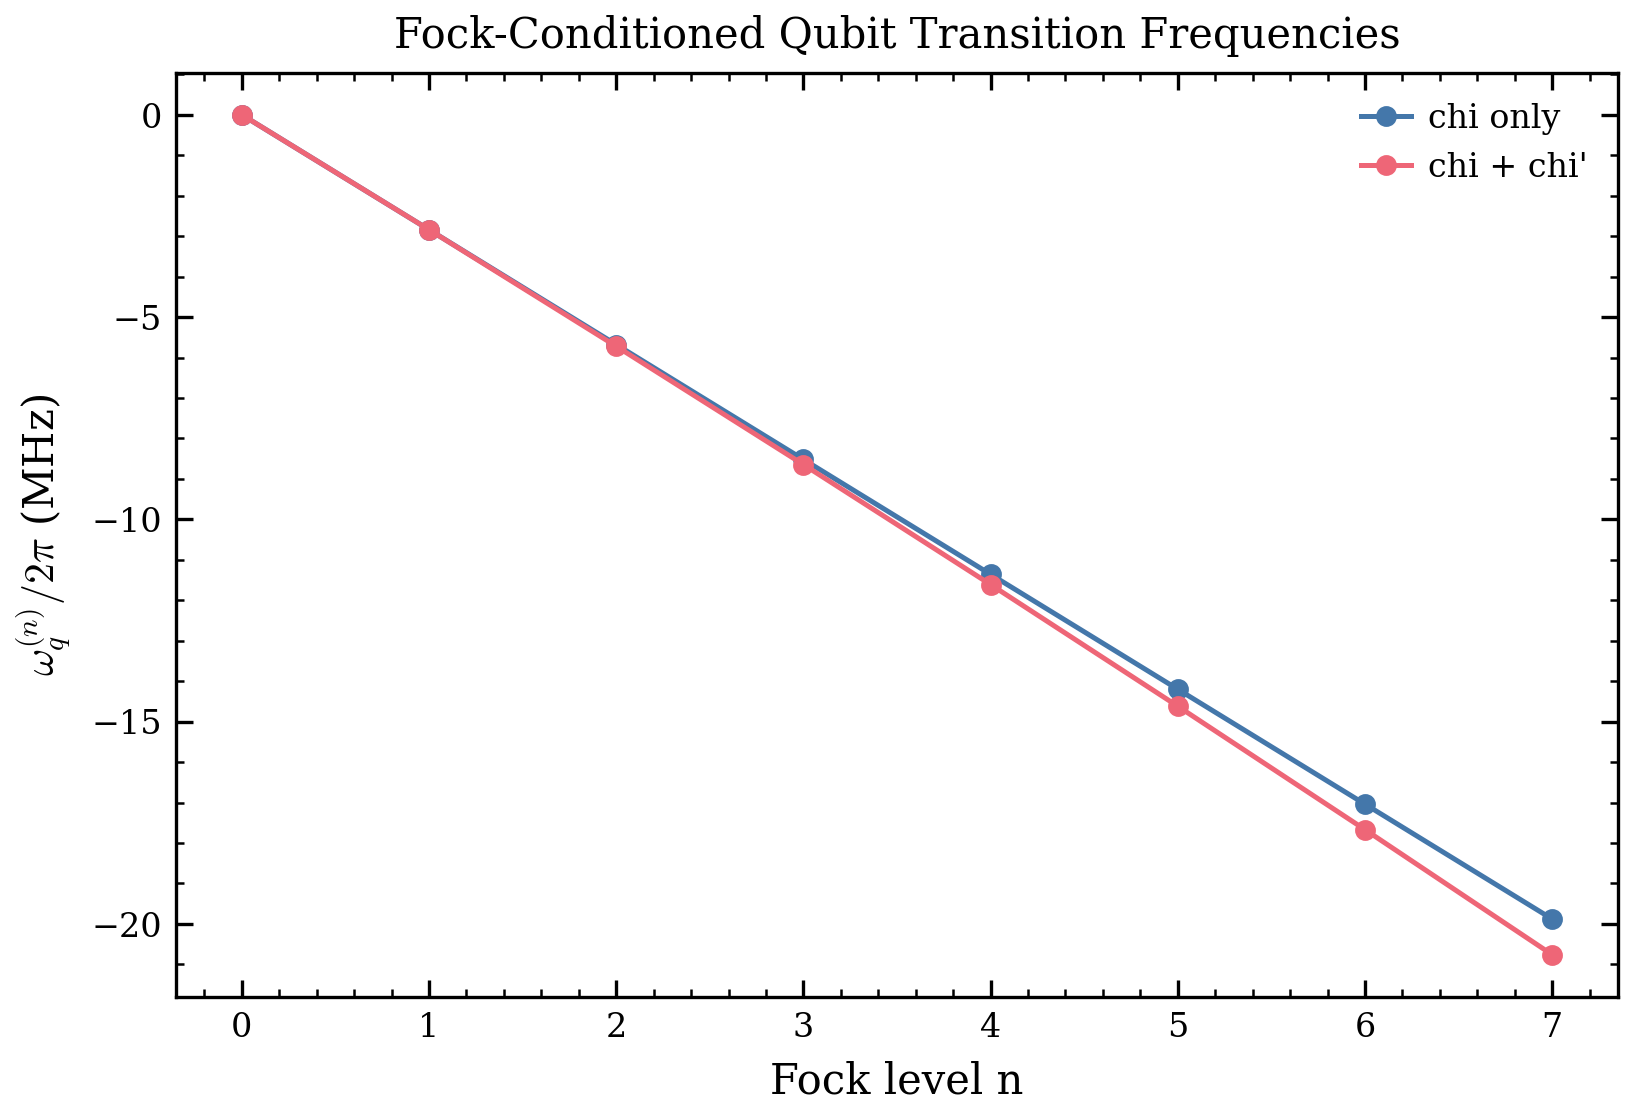

### Fidelity Vs Pulse Duration

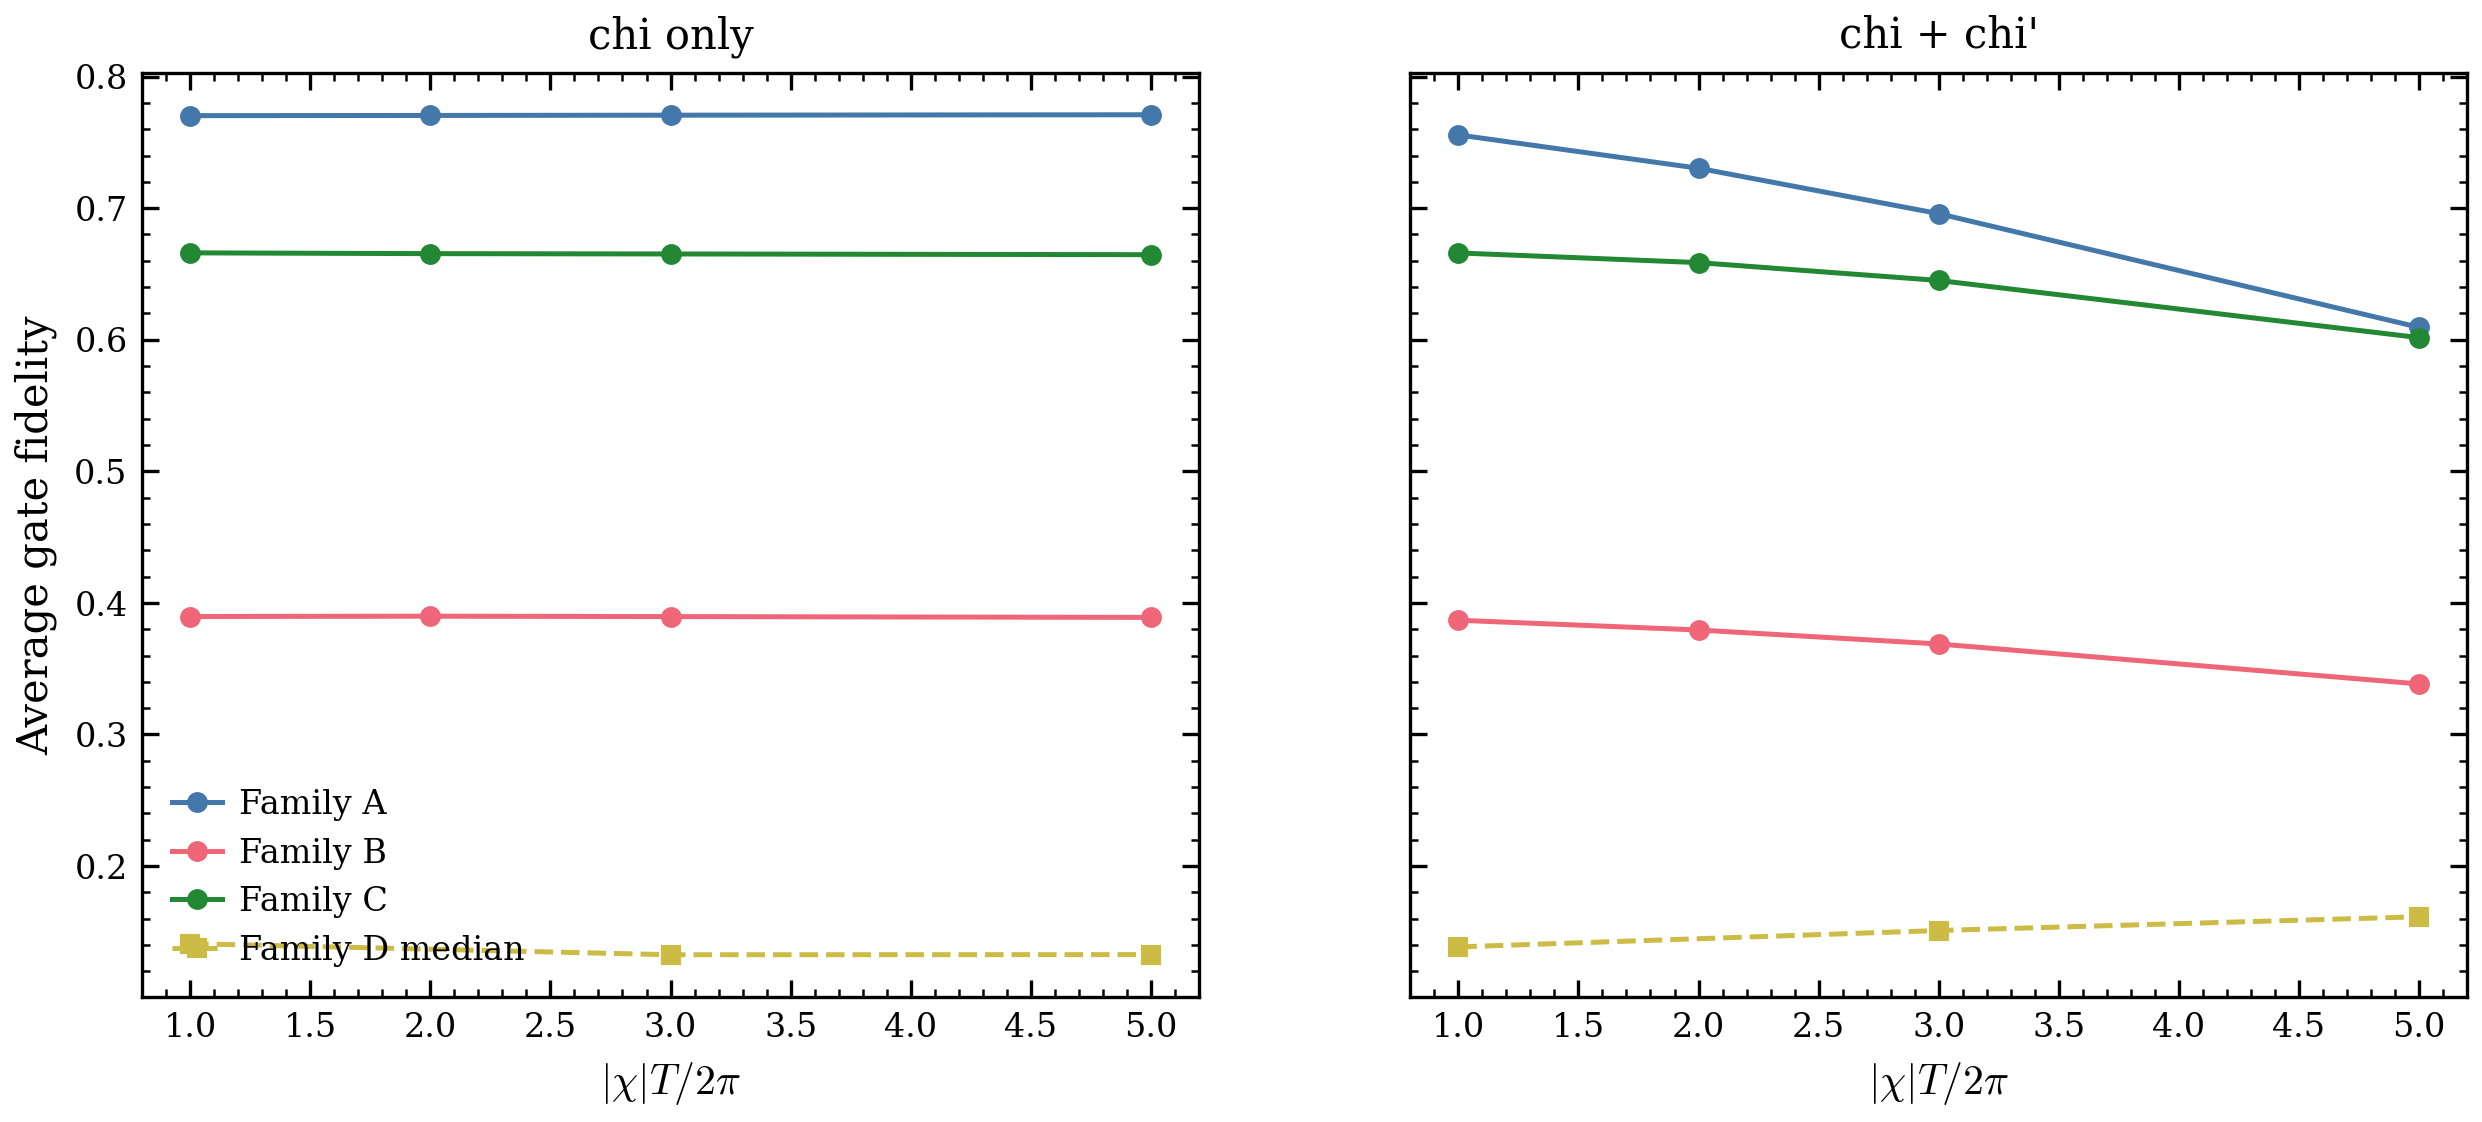

### Fidelity Vs Active Subspace Size

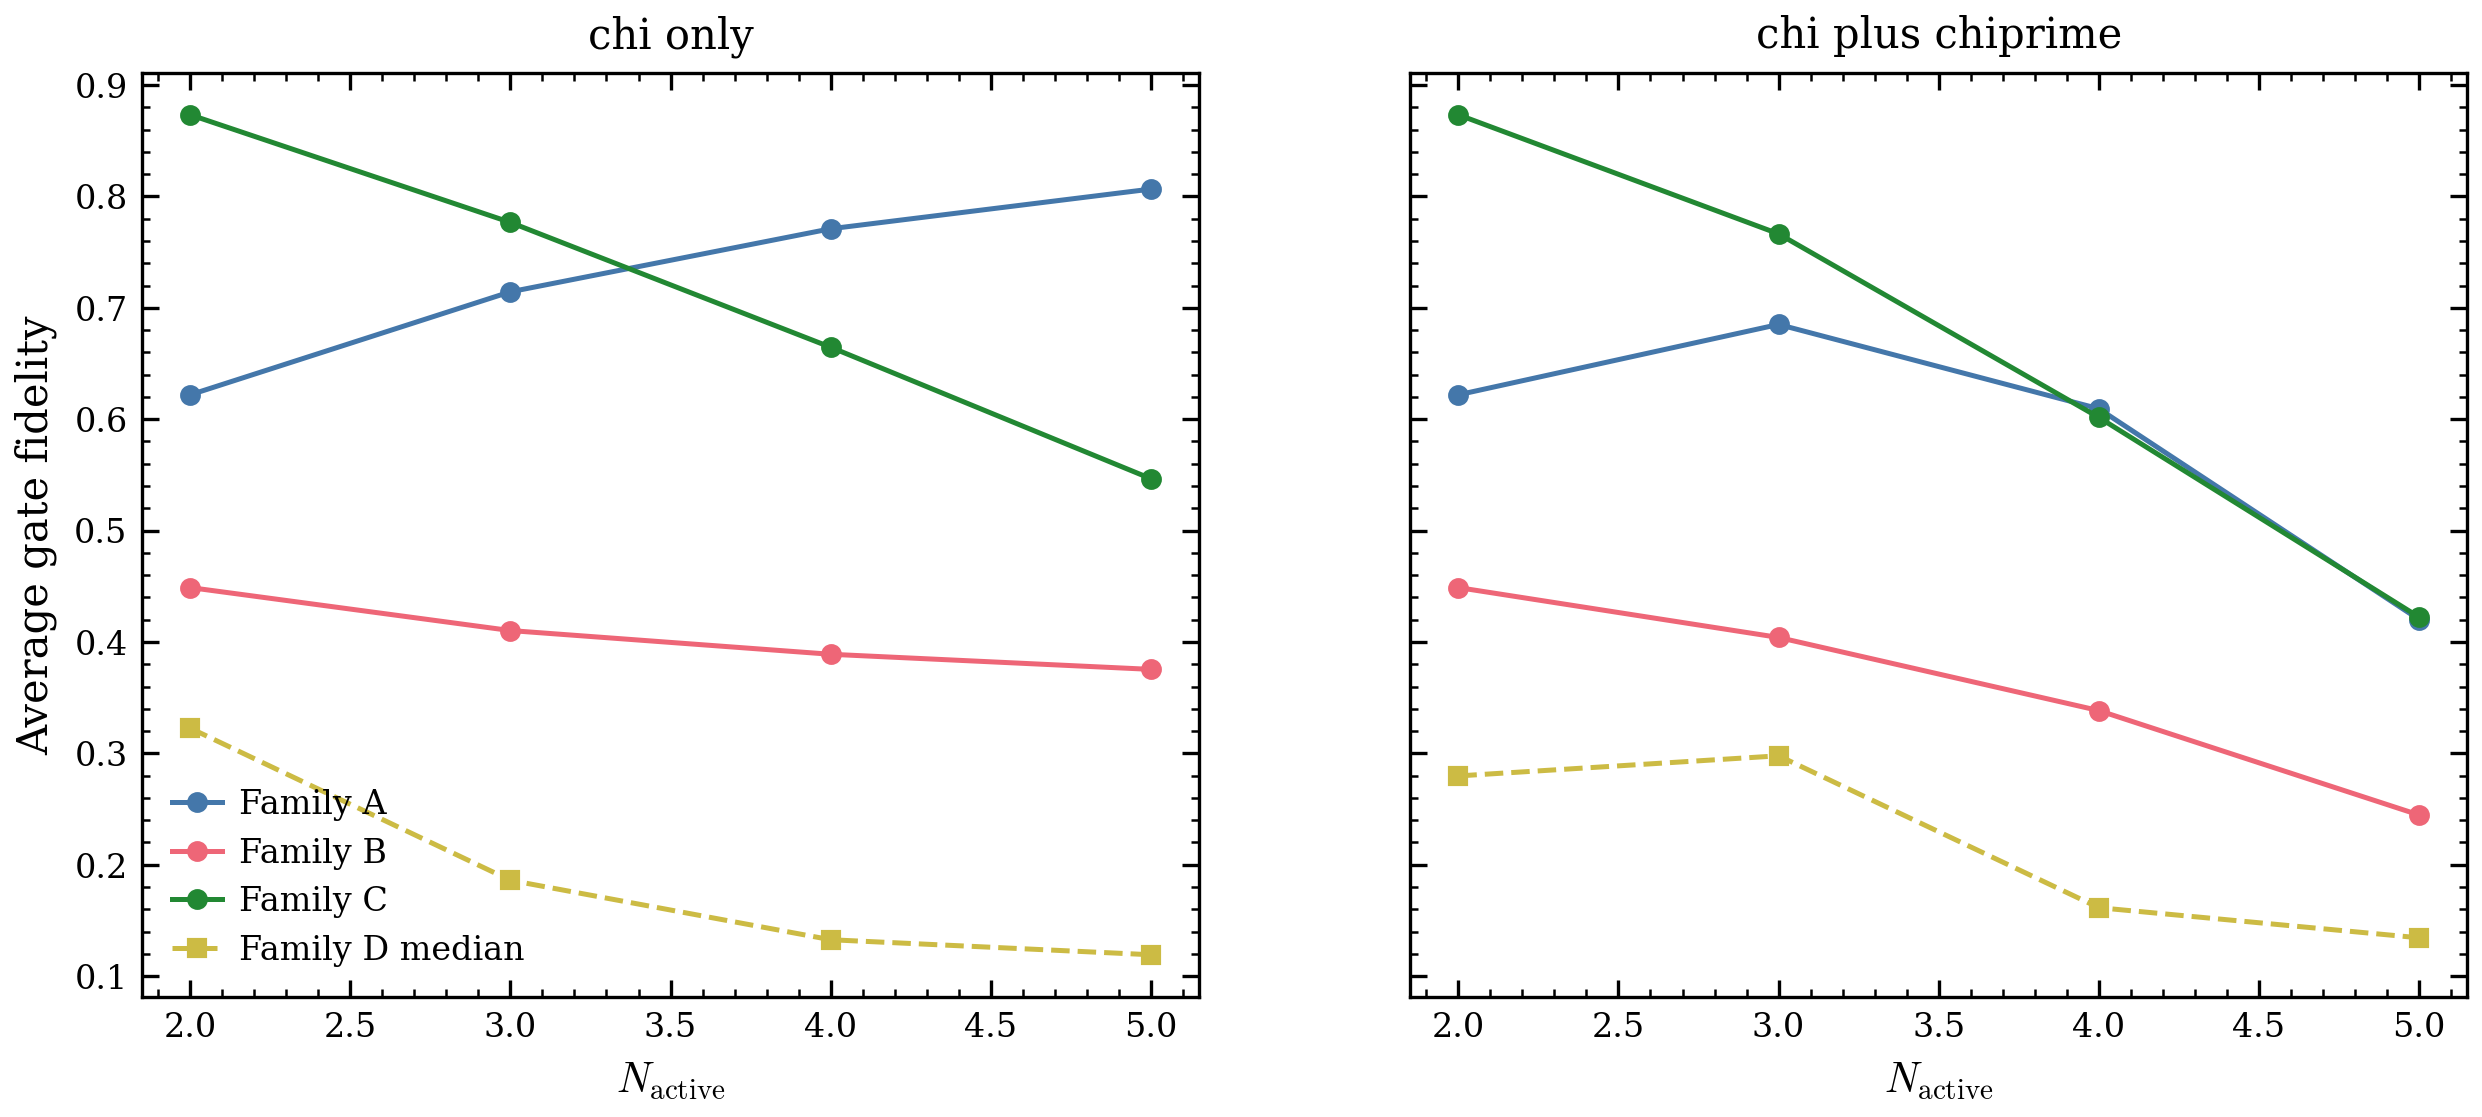

### Random Target Fidelity Histogram

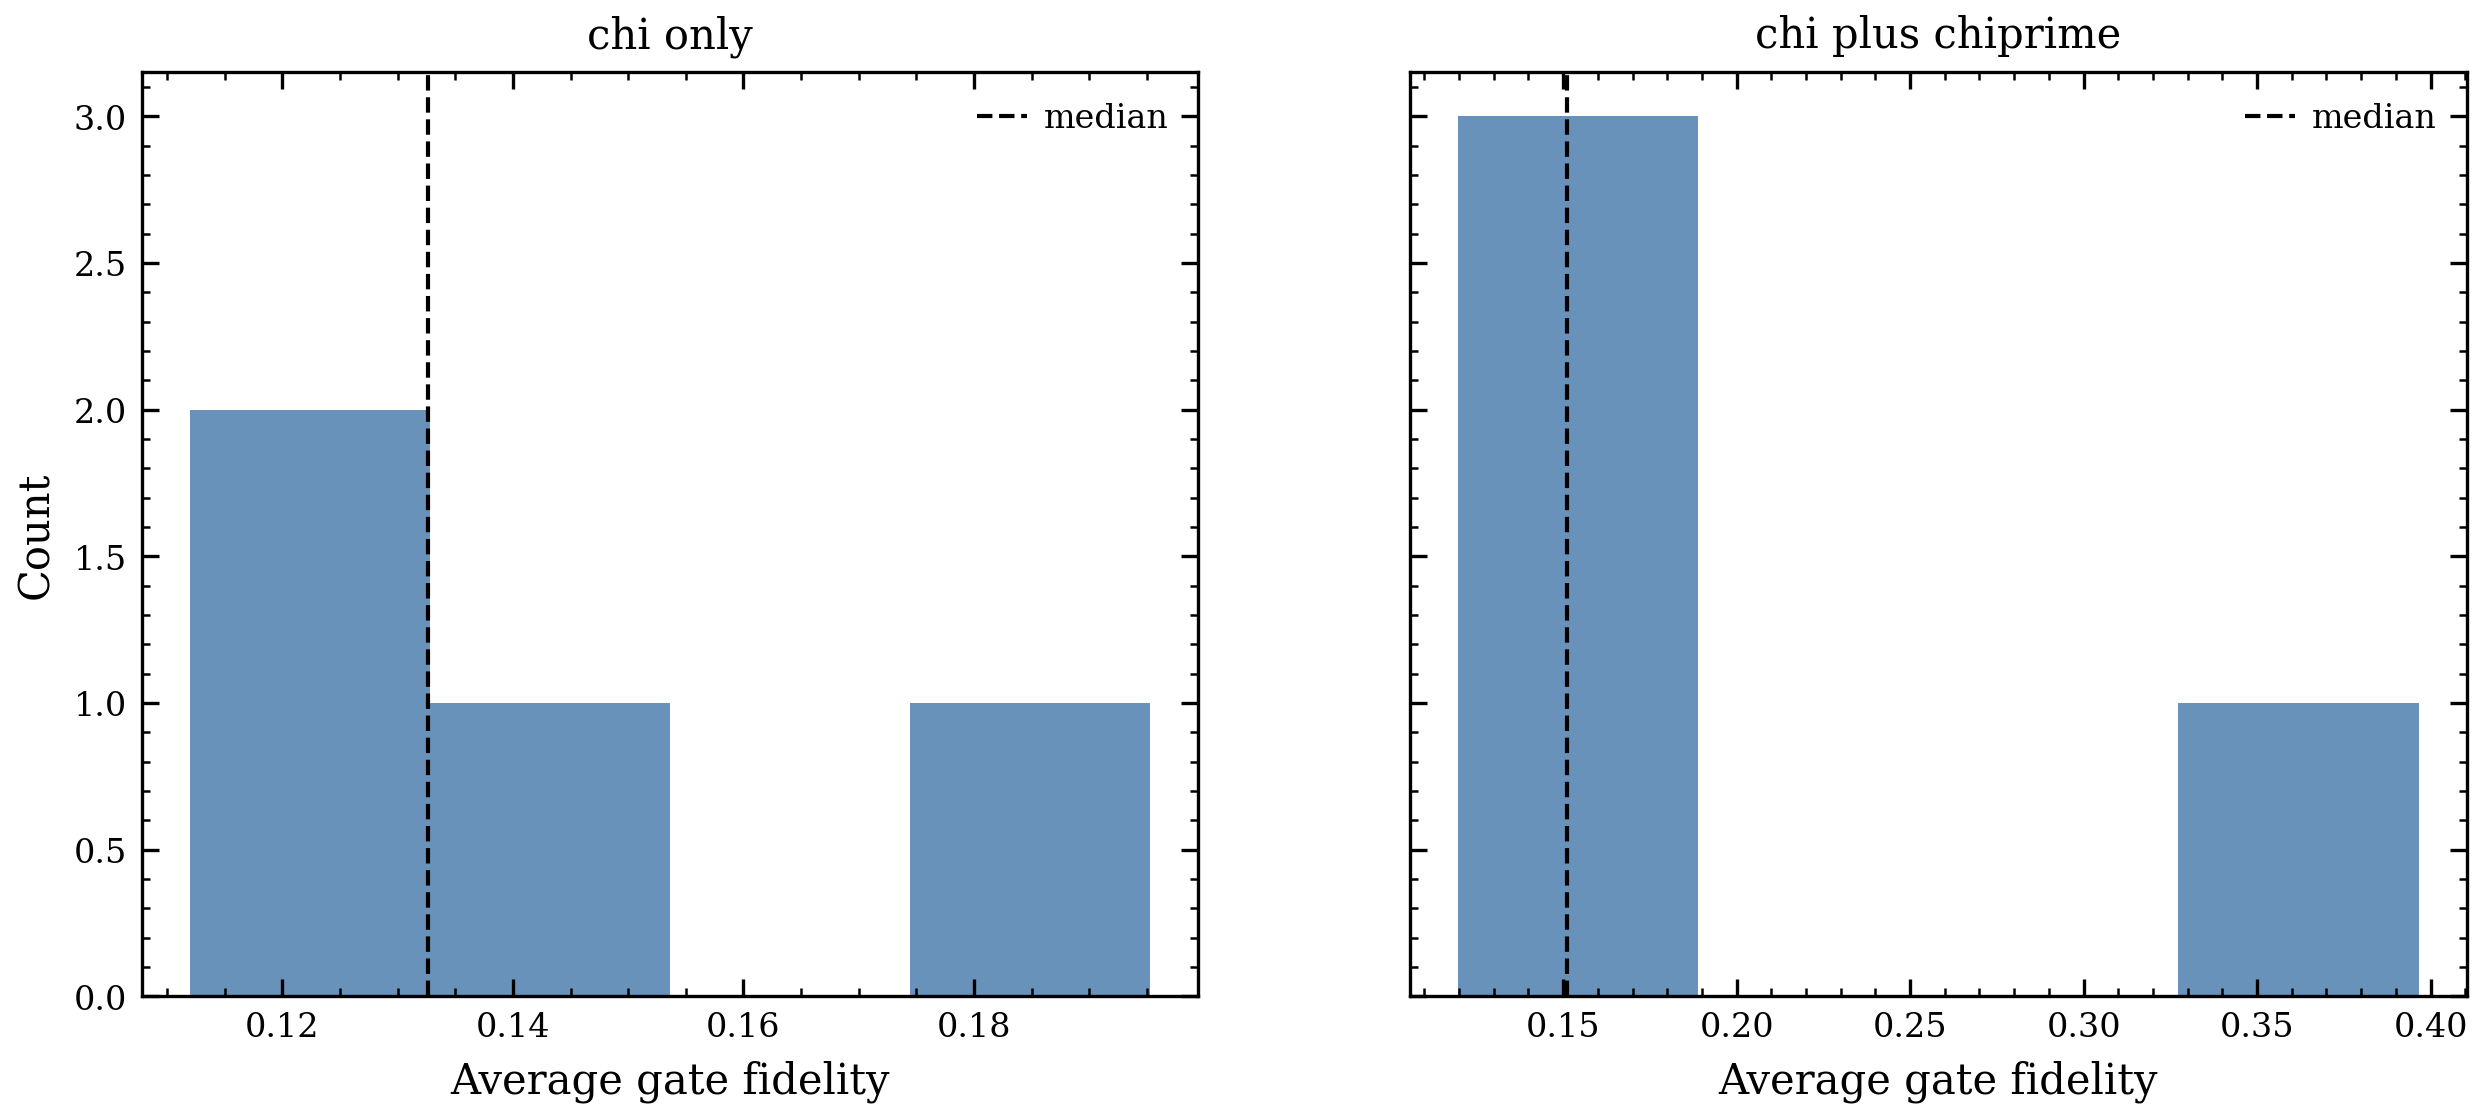

### Chi Only Vs Chi Plus Chiprime

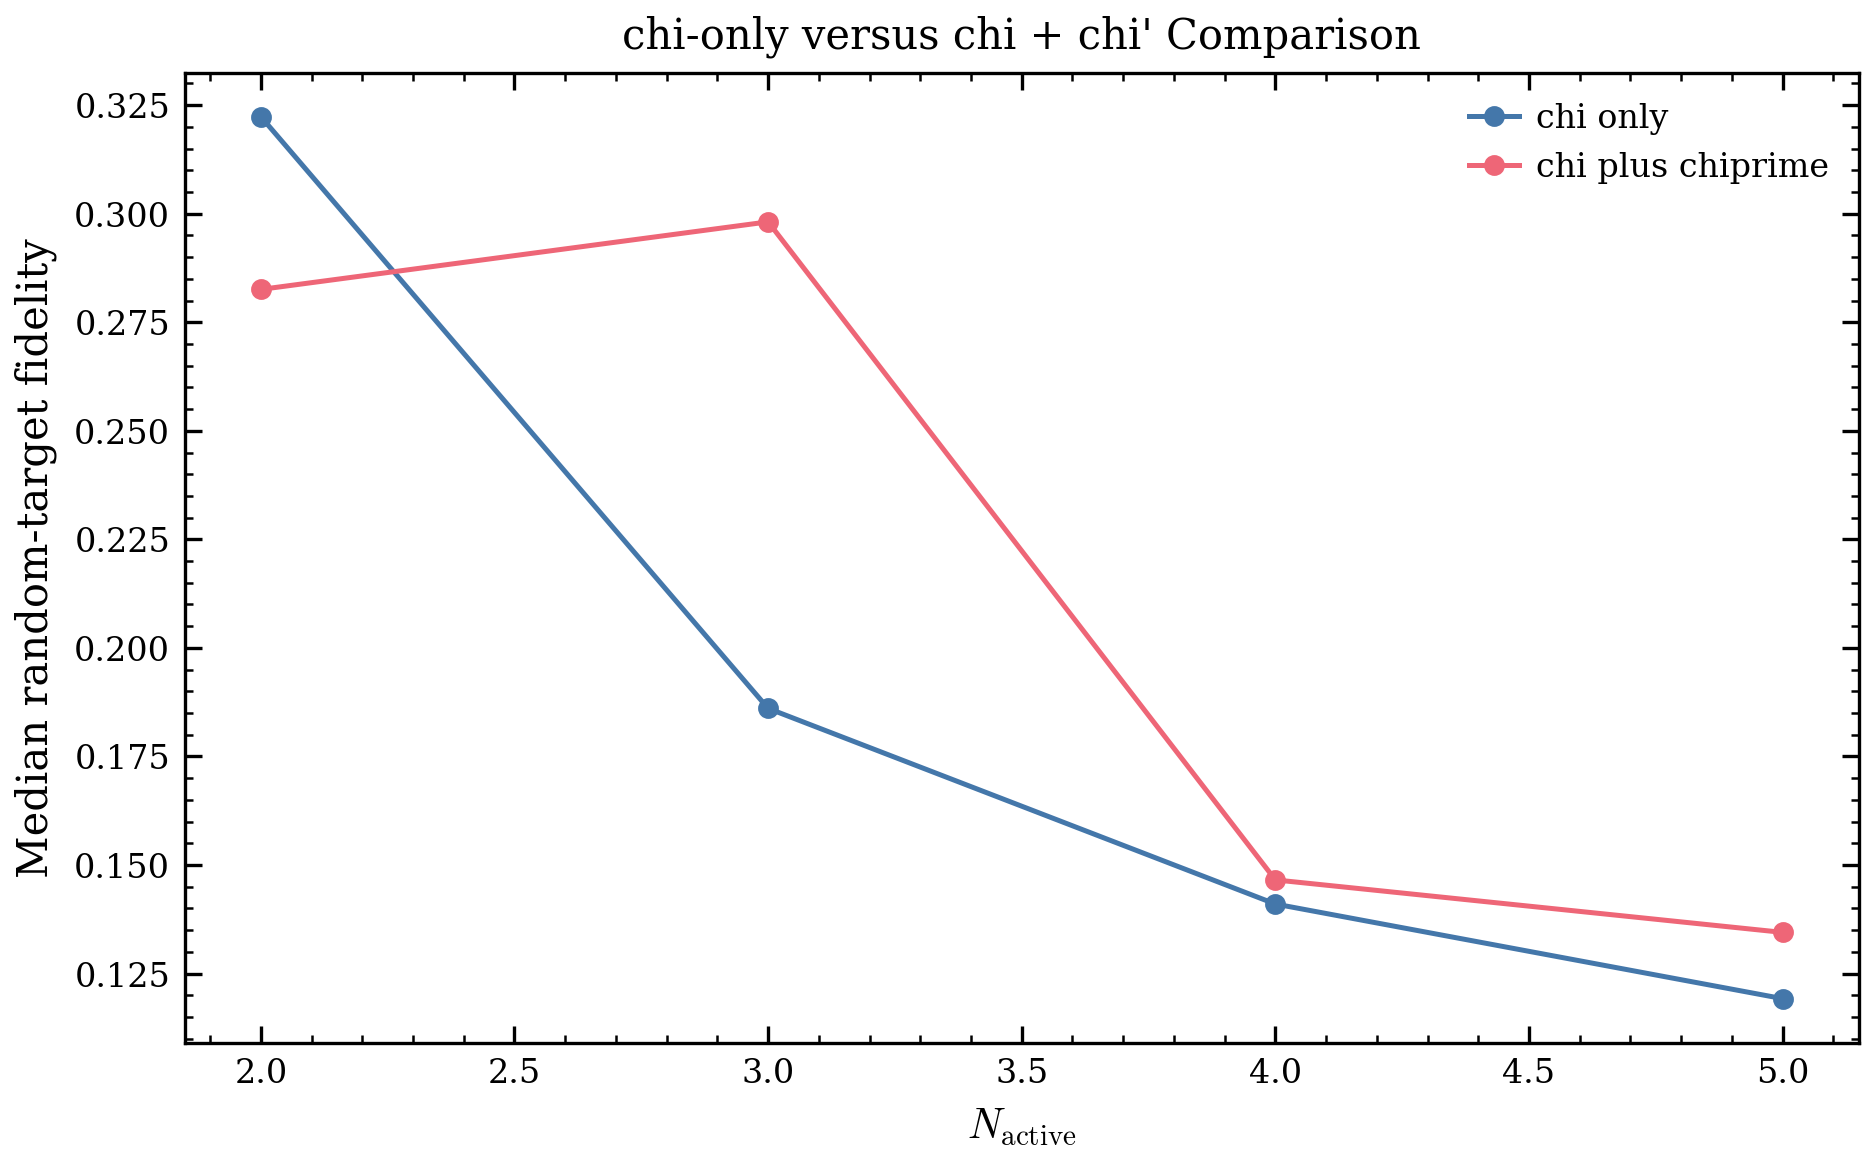

In [ ]:
# --- Load saved results (default) ---
for stem in PARAMS['figure_stems']:
    display(Markdown(f"### {stem.replace('_', ' ').title()}"))
    display(Image(filename=str(FIGURES_DIR / f'{stem}.png')))

## Optional full comparison rerun

This commented cell reruns the full echoed comparison sweep from scratch. It is intentionally disabled because it rewrites the combined comparison outputs, figures, and highlight artifacts.

In [ ]:
# --- Re-run with current parameters ---
# import subprocess
# subprocess.run([sys.executable, str(SCRIPTS_DIR / 'run_echo_comparison.py')], check=True)

## Validation outputs

This cell loads the saved validation summary produced by `validate_echo_comparison.py`. It reports artifact checks, explicit sequence-order validation, inheritance of the original single-pulse validation, and convergence replays for the best echoed case.

In [ ]:
validation_checks = pd.DataFrame(comparison_validation['checks'])
display(validation_checks[['name', 'passed']])
for item in comparison_validation['checks']:
    display(Markdown(f"### {item['name']}"))
    display(pd.DataFrame([item['details']]))

,name,passed
0,artifacts_present,True
1,zero_drive_identity_sanity,True
2,single_manifold_sanity,True
3,time_step_convergence,True
4,truncation_convergence,True
5,chi_prime_random_ensemble_comparison,True
6,literature_comparison,True


### time_step_convergence

,best_random,best_structured
0,0.0043,-0.000512


### truncation_convergence

,best_random,best_structured
0,-7.412856e-07,-5.124416e-07


### chi_prime_random_ensemble_comparison

,interpretation,median_chi_only,median_chi_plus_chiprime,median_difference
0,The sampled random-target median shifts slight...,0.1326,0.151017,-0.018417


## Optional validation re-run

This cell is commented out because it reruns the echoed-extension validation script. Use it only after regenerating the comparison outputs or changing the replay settings in the parameter cell above.

In [ ]:
# --- Re-run with current parameters ---
# import subprocess
# subprocess.run([sys.executable, str(SCRIPTS_DIR / 'validate_echo_comparison.py')], check=True)

## Summary

The previous report tested only the single Gaussian multitone SQR pulse and therefore supported only a narrow ansatz-level negative conclusion. The updated study now explicitly tests the time-ordered echoed schedule `half SQR -> X_pi -> half SQR -> X_pi` under both fixed-total and fixed-active timing conventions.

What the saved comparison shows:
- The exact repeated-half echoed construction does **not** rescue the strongest structured family C cases. Their median fidelity collapses from about `0.777` for `single_pulse` to about `0.211` (`echoed_fixed_total`) and `0.172` (`echoed_fixed_active`).
- The echoed construction is not uniformly harmful. On the random family D subset, `echoed_fixed_active` improves fidelity in `38/72` matched cases and reduces residual-Z error in `38/72` matched cases.
- The best echoed case is `chi_only_na3_chiT5p0_familyD_seed317160` with `echoed_fixed_total`, reaching average gate fidelity `0.606132`, but this still remains well below the best baseline single-pulse structured case at `0.873625`.

The best current scientific reading is therefore: the earlier negative result was a failure of the single Gaussian multitone SQR ansatz, not a proof that all composite SQR constructions fail. The newly tested explicit echoed sequence partially mitigates some random-target cases but does not solve the broader arbitrary-control problem and badly degrades the strongest structured targets.

| Parameter | Default value | Effect on outputs |
| --- | --- | --- |
| `comparison_group` | `chi_only_na3_chiT5p0_familyD_seed317160` | Chooses the matched single-vs-echo comparison case to inspect. |
| `sequence_family` | `echoed_fixed_total` | Selects which saved branch row and artifact are loaded for that matched case. |
| `validation_dt_s` | `2e-9` | Intended finer compilation step for optional echoed validation reruns. |
| `extra_cavity_levels` | `2` | Intended cavity-padding increase for optional echoed validation reruns. |
| `figure_stems` | five echoed-comparison figure names | Controls which saved comparison figures are displayed in the notebook. |

Caveat: this notebook reproduces the exact echoed schedule that was tested here. It does not yet cover independently parameterized echoed halves, ideal instantaneous refocusing pulses, or richer segmented composite waveforms.